# Model Fitting

Use this notebook to orchestrate a single model fit, simulate from the fitted parameters, and generate benchmark diagnostics.

In [1]:
import inspect
import json
import os
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
)
from jaxcmr.math import cosine_similarity_matrix
from jaxcmr.simulation import simulate_h5_from_h5
from jaxcmr.summarize import summarize_parameters
from jaxcmr.typing import AnalysisConfig

warnings.filterwarnings("ignore")

## Parameter Setup

In [ ]:
# Data parameters
base_data_tag = "HealeyKahana2014"
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
embedding_path = "data/peers-all-mpnet-base-v2.npy"
features_path = "data/emotion_features_7col.npy"
feature_column = 6 
trial_query = "data['listtype'] == -1"
target_directory = "results/"

# Algorithm selection
model_name = "WeirdCMRNoStop"
model_factory_path = "jaxcmr.models.weird_cmr_no_stop.BaseCMRFactory"
sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.transform_likelihood.ExcludeTerminationLikelihoodFnGenerator"
fit_alg_path = "jaxcmr.fitting.ScipyDE"

# Run configuration
base_run_tag = "fixed_term"
experiment_count = 50
max_subjects = 0
seed = 0

# Flow toggles
allow_repeated_recalls = False
filter_repeated_recalls = True
handle_elis = False
redo_fits = False
redo_sims = False
redo_figures = True

# fitting hyperparameters
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 3
parameters = {
    "fixed": {},
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    },
}

# analysis configuration
comparison_analysis_configs = [
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
        "kwargs": {"query_study_position": 1},
    },
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve"
    },
    {"target": "jaxcmr.analyses.distcrp.plot_dist_crp"},
    {"target": "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve"},
    {"target": "jaxcmr.analyses.termination_probability.plot_termination_probability"},
    {"target": "jaxcmr.analyses.spc.plot_spc"},
    {"target": "jaxcmr.analyses.crp.plot_crp"},
    {"target": "jaxcmr.analyses.pnr.plot_pnr"},
]

In [ ]:
# derive run tag
run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# set up rng
rng = random.PRNGKey(seed)

# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product in ["fits", "figures", "simulations"]:
    product_dir = os.path.join(target_directory, product)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# load data
data = load_data(os.path.join(find_project_root(), data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load embeddings and compute distance matrix
max_size = np.max(data["pres_itemnos"])
embeddings = np.load(os.path.join(find_project_root(), embedding_path))
connections = cosine_similarity_matrix(embeddings)
distances = 1 - connections
features = np.load(os.path.join(find_project_root(), features_path)).astype(np.float32)
feature_values = features[:, feature_column].astype(np.float32)
categorical_distances = np.abs(feature_values[:, None] - feature_values[None, :])

# import model and analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model", "Data"))))
    contrast_name = config.get("contrast_name", "Source")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))
    
    # choose a distance matrix based on the function name
    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name:
        extra_kwargs.setdefault("distances", distances)
    elif "cat_" in analysis_name:
        extra_kwargs.setdefault("distances", categorical_distances)

    comparison_analyses.append(
        AnalysisConfig(
            target=analysis_fn,
            figure_suffix=str(figure_suffix),
            labels=labels,
            contrast_name=str(contrast_name),
            kwargs=extra_kwargs,
        )
    )

model_factory = import_from_string(model_factory_path)
BaseCMR = import_from_string(
    model_factory_path[: model_factory_path.rfind(".")] + ".BaseCMR"
)

# import fitting and simulation functions
fitting_algorithm = import_from_string(fit_alg_path)
loss_fn_generator = import_from_string(loss_fn_path)
simulate_trial_fn = import_from_string(sim_alg_path)

# derive list of query parameters from keys of `parameters`
parameters["fixed"]["allow_repeated_recalls"] = allow_repeated_recalls
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )

## Fit Model

In [4]:
fit_path = Path(product_dirs["fits"]) / f"{data_tag}_{model_name}_{run_tag}.json"
metadata = {
    "data_query": trial_query,
    "model": model_name,
    "name": f"{data_tag}_{model_name}_{run_tag}",
}

if fit_path.exists() and not redo_fits:
    with fit_path.open() as handle:
        results = json.load(handle)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results.get("subject", [])
    results |= metadata

else:
    fitter = fitting_algorithm(
        data,
        connections,
        parameters["fixed"],
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "best_of": best_of,
            "bounds": parameters["free"],
        },
    )

    results = fitter.fit(trial_mask) | metadata
    with fit_path.open("w") as handle:
        json.dump(results, handle, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)

| Parameter | Statistic | HealeyKahana2014 WeirdCMRNoStop fixed term best of 3 |
|---|---|---|
| fitness | mean | 525.15 +/- 17.15 |
|  | std | 96.90 |
|  | min | 253.08 |
|  | max | 743.77 |
| encoding drift rate | mean | 0.78 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.15 |
|  | max | 0.99 |
| start drift rate | mean | 0.13 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.00 |
|  | max | 0.80 |
| recall drift rate | mean | 0.85 +/- 0.02 |
|  | std | 0.12 |
|  | min | 0.52 |
|  | max | 1.00 |
| shared support | mean | 8.27 +/- 1.91 |
|  | std | 10.78 |
|  | min | 0.00 |
|  | max | 80.36 |
| item support | mean | 18.24 +/- 4.20 |
|  | std | 23.72 |
|  | min | 0.00 |
|  | max | 99.14 |
| learning rate | mean | 0.28 +/- 0.04 |
|  | std | 0.23 |
|  | min | 0.00 |
|  | max | 0.96 |
| primacy scale | mean | 16.09 +/- 4.14 |
|  | std | 23.40 |
|  | min | 0.31 |
|  | max | 99.19 |
| primacy decay | mean | 20.01 +/- 5.00 |
|  | std | 28.25 |
|  | min | 0.00 |
|  | max | 98.19 |
| choice sensitivity | m

## Simulate From Fit

In [5]:
# either load or perform model simulations

sim_path = os.path.join(
    product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}.h5"
)
print(sim_path)

rng, rng_iter = random.split(rng)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if os.path.exists(sim_path) and not redo_sims:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory=model_factory,
        dataset=data,
        connections=connections,
        parameters=params,
        trial_mask=trial_mask,
        experiment_count=experiment_count,
        rng=rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path)  # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])


results/simulations/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3.h5
Loaded from results/simulations/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3.h5


## Figures

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_conditional_nth_item_recall_curve.png)


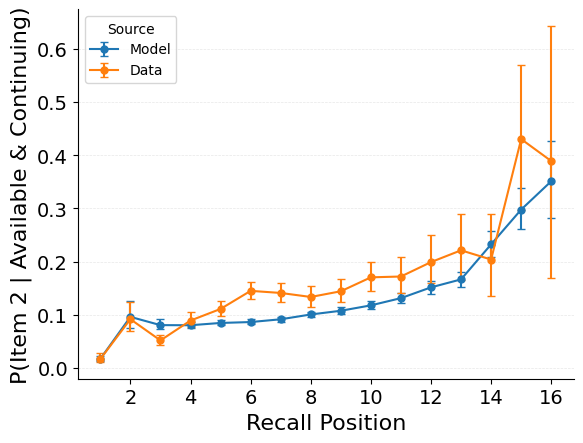

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_conditional_nth_item_recall_curve.png)


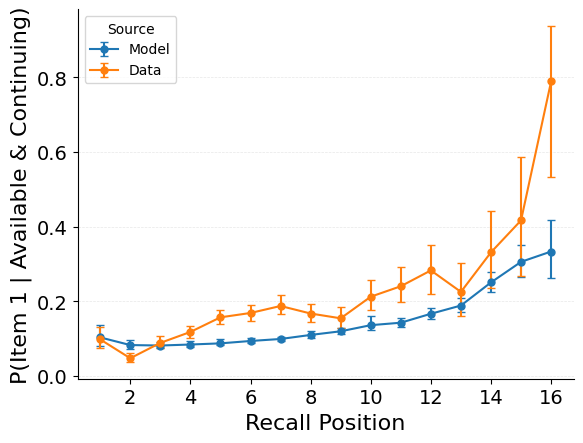

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_dist_crp.png)


TypeError: plot_dist_crp() missing 1 required positional argument: 'distances'

In [6]:
# generate figures comparing model and data
for analysis_cfg in comparison_analyses:
    analysis_fn = analysis_cfg.target
    figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis_cfg.figure_suffix}.png"
    figure_path = os.path.join(product_dirs["figures"], figure_str)
    print(f"![]({figure_path})")

    # if not redo_figures, check if figure already exists and don't redo
    # we want to display the figure here if it already exists
    if os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]

    # Create masks for the selected list types
    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    base_kwargs = {
        "datasets": [sim, data],
        "trial_masks": [np.array(sim_trial_mask), np.array(trial_mask)],
        "color_cycle": color_cycle,
        "labels": list(analysis_cfg.labels),
        "contrast_name": analysis_cfg.contrast_name,
        "axis": None,
    }
    base_kwargs |= analysis_cfg.kwargs

    signature = inspect.signature(analysis_fn)
    filtered_kwargs = {
        name: value
        for name, value in base_kwargs.items()
        if name in signature.parameters
    }

    axis = analysis_fn(**filtered_kwargs)

    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()